In [1]:
import matplotlib.pyplot as plt
import numpy as np
#import pandas as pd
import matplotlib
import pandas as pd
import mne
import os
from mne.preprocessing import ICA
from scipy.stats import pearsonr
import seaborn as sns


Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD031\EEG\SD031.vhdr...
Setting channel info structure...
Reading 0 ... 2373159  =      0.000 ...  2373.159 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
Using matplotlib as 2D backend.


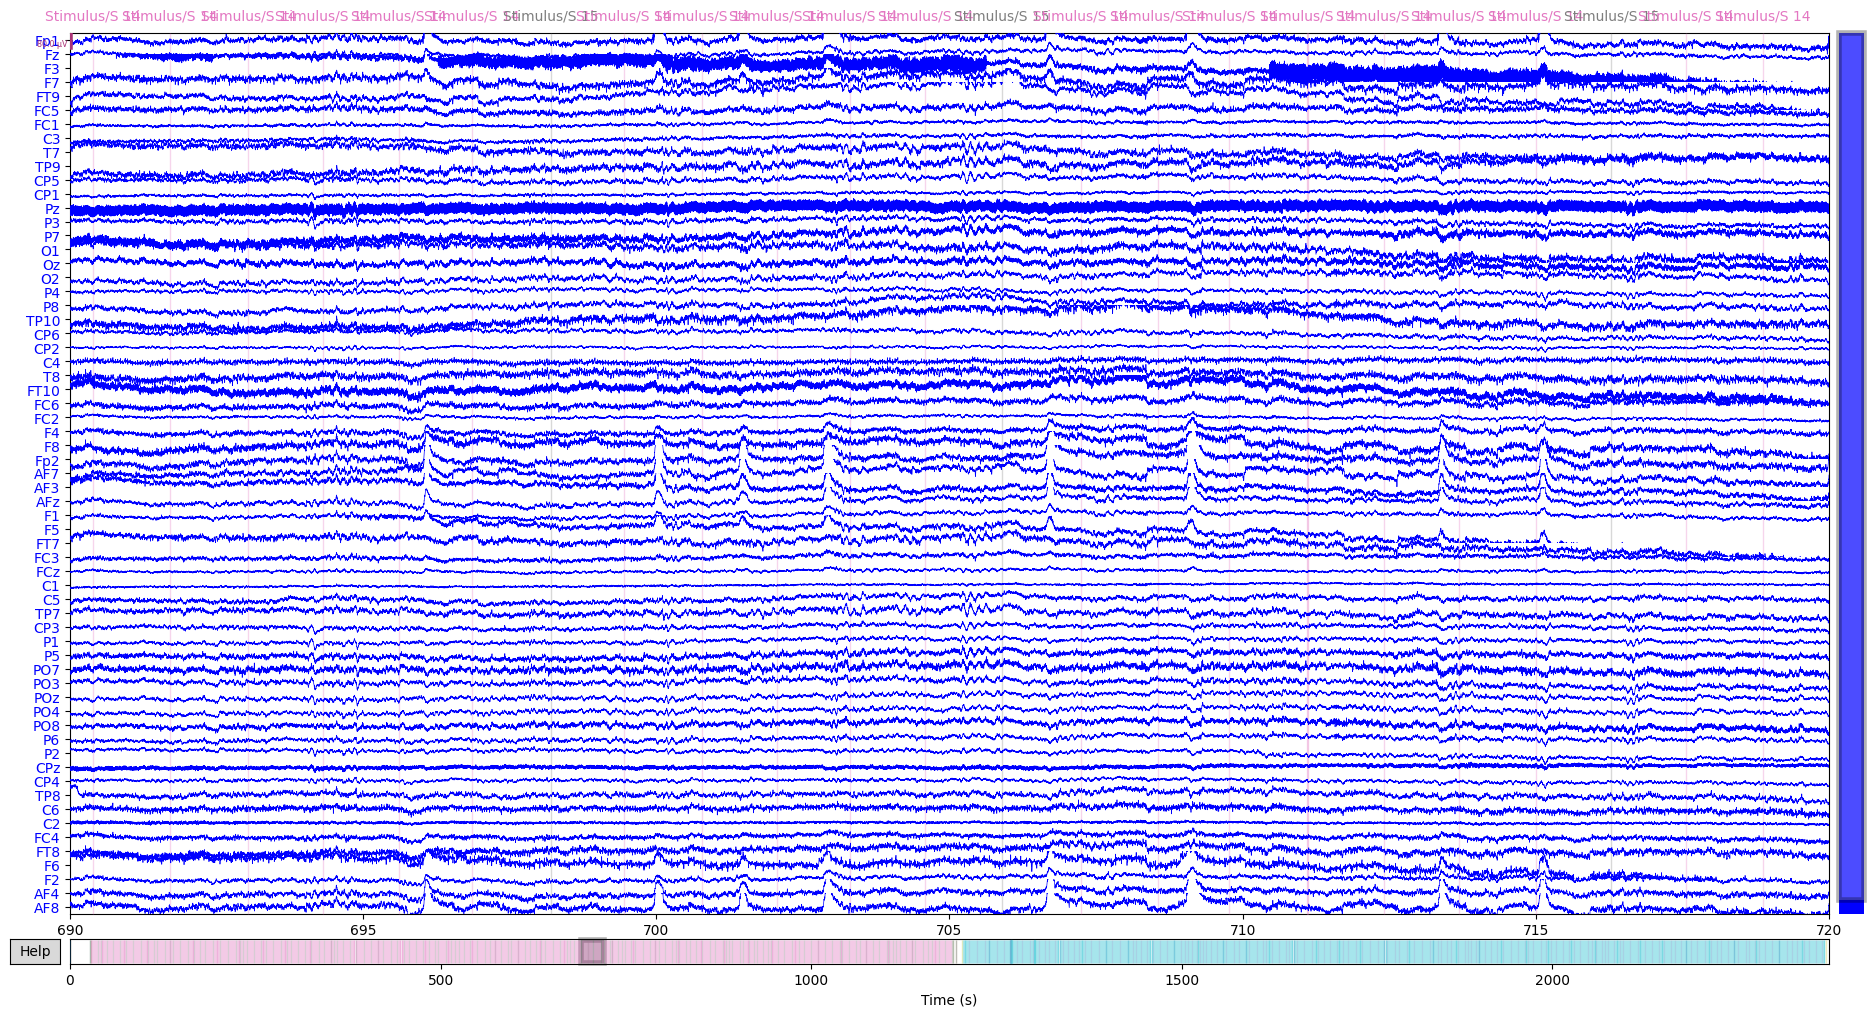

Approximating Fpz location by mirroring Oz along the X and Y axes.


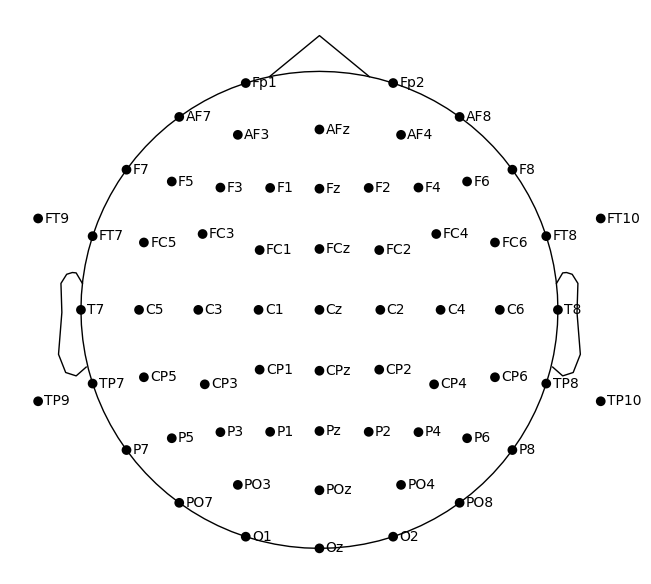

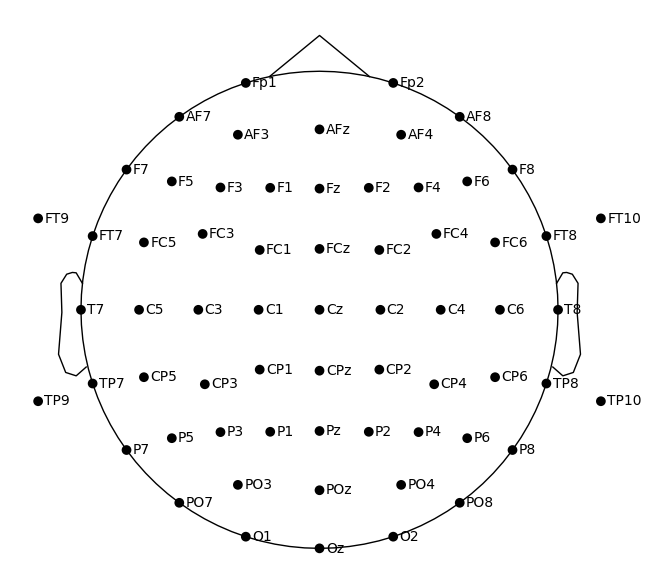

In [2]:
data_folder = r"D:\Work_data\Notification_evoked_response\Data_at_IITD/"
subjects = os.listdir(data_folder)
data_type = "EEG"
subject = "SD031"
path = os.path.join(data_folder,subject,data_type)
for eeg in os.listdir(path):
    if eeg[-5:] == ".vhdr":
            break
raw = mne.io.read_raw_brainvision(os.path.join(path,eeg), preload=True)
raw = mne.add_reference_channels(raw, ref_channels=["Cz"])
raw.set_montage("easycap-M1")
raw.plot(scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue",event_color ='black',show_options=True )
raw.plot_sensors(show_names=True, sphere="eeglab")

Used Annotations descriptions: ['Comment/Active Shielding: On', 'New Segment/', 'Stimulus/S 11', 'Stimulus/S 12', 'Stimulus/S 13', 'Stimulus/S 14', 'Stimulus/S 15', 'Stimulus/S 21', 'Stimulus/S 24', 'Stimulus/S 25']
[   11    12    13    14    15    21    24    25 10001 99999]
Not setting metadata
750 matching events found
Setting baseline interval to [-1.3, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 750 events and 3001 original time points ...
0 bad epochs dropped


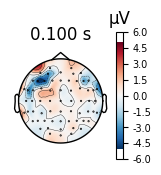

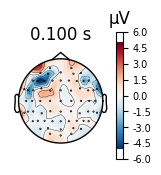

In [ ]:
events,event_dict = mne.events_from_annotations(raw)
unique_event_ids = np.unique(events[:, 2])
print(unique_event_ids)
epochs = mne.Epochs(raw, events, event_id=[14],baseline=(None, 0), tmin=-1.300, tmax=1.700, preload=True)

evoked = epochs.average()

# Now you can plot a topomap at specific times (in seconds)
evoked.plot_topomap(times=0.1, ch_type='eeg') 



In [29]:
event_id=[14,17 ,16,21,22 ]

unique_event_ids
non_event = []
for i in event_id:
    if i  not in unique_event_ids:
        
        non_event.append(i)
        event_id.remove(i)
print(non_event, " is not in Array")
print(event_id)
epochs.events

[17, 22]  is not in Array
[14, 16, 21]


array([[  28200,       0,      14],
       [  29567,       0,      14],
       [  30866,       0,      14],
       ...,
       [1187090,       0,      14],
       [1188390,       0,      14],
       [1190939,       0,      14]])

FCz
Approximating Fpz location by mirroring Oz along the X and Y axes.


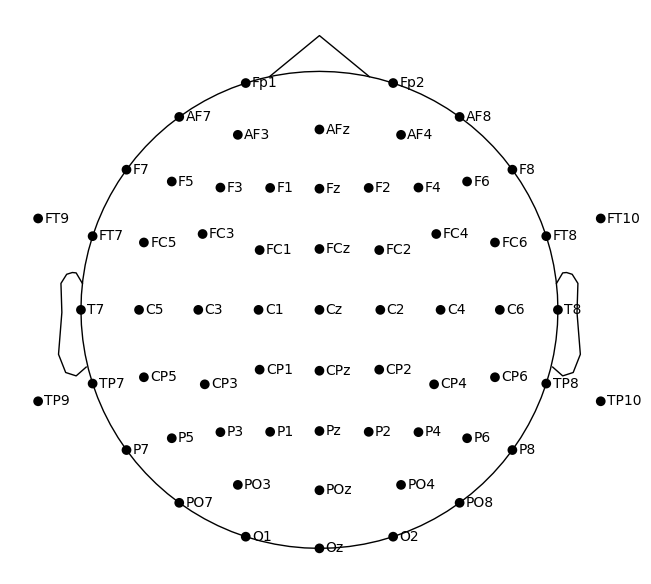

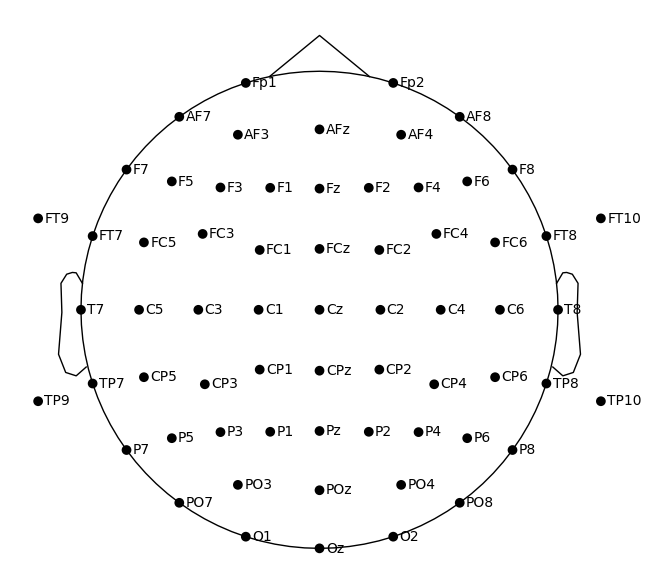

In [75]:
print(raw.info['ch_names'].copy().pop(38))
raw.plot_sensors(show_names=True, sphere="eeglab")

In [28]:
a = []
if not a:
    print(a)

[]


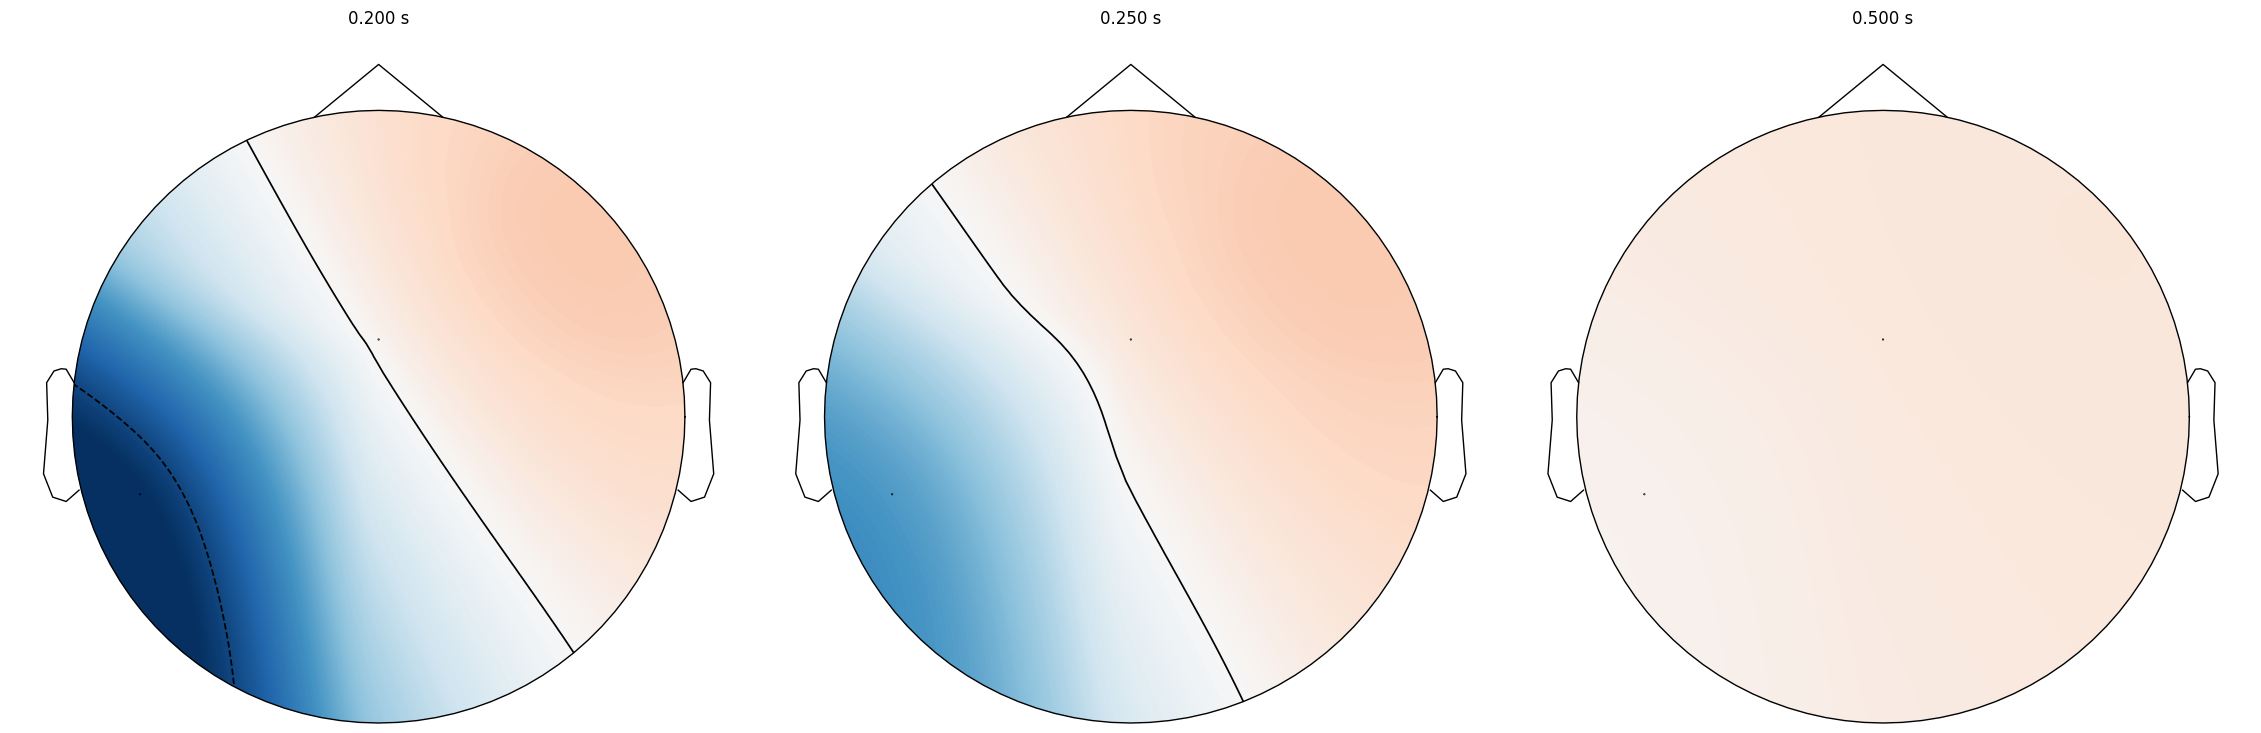

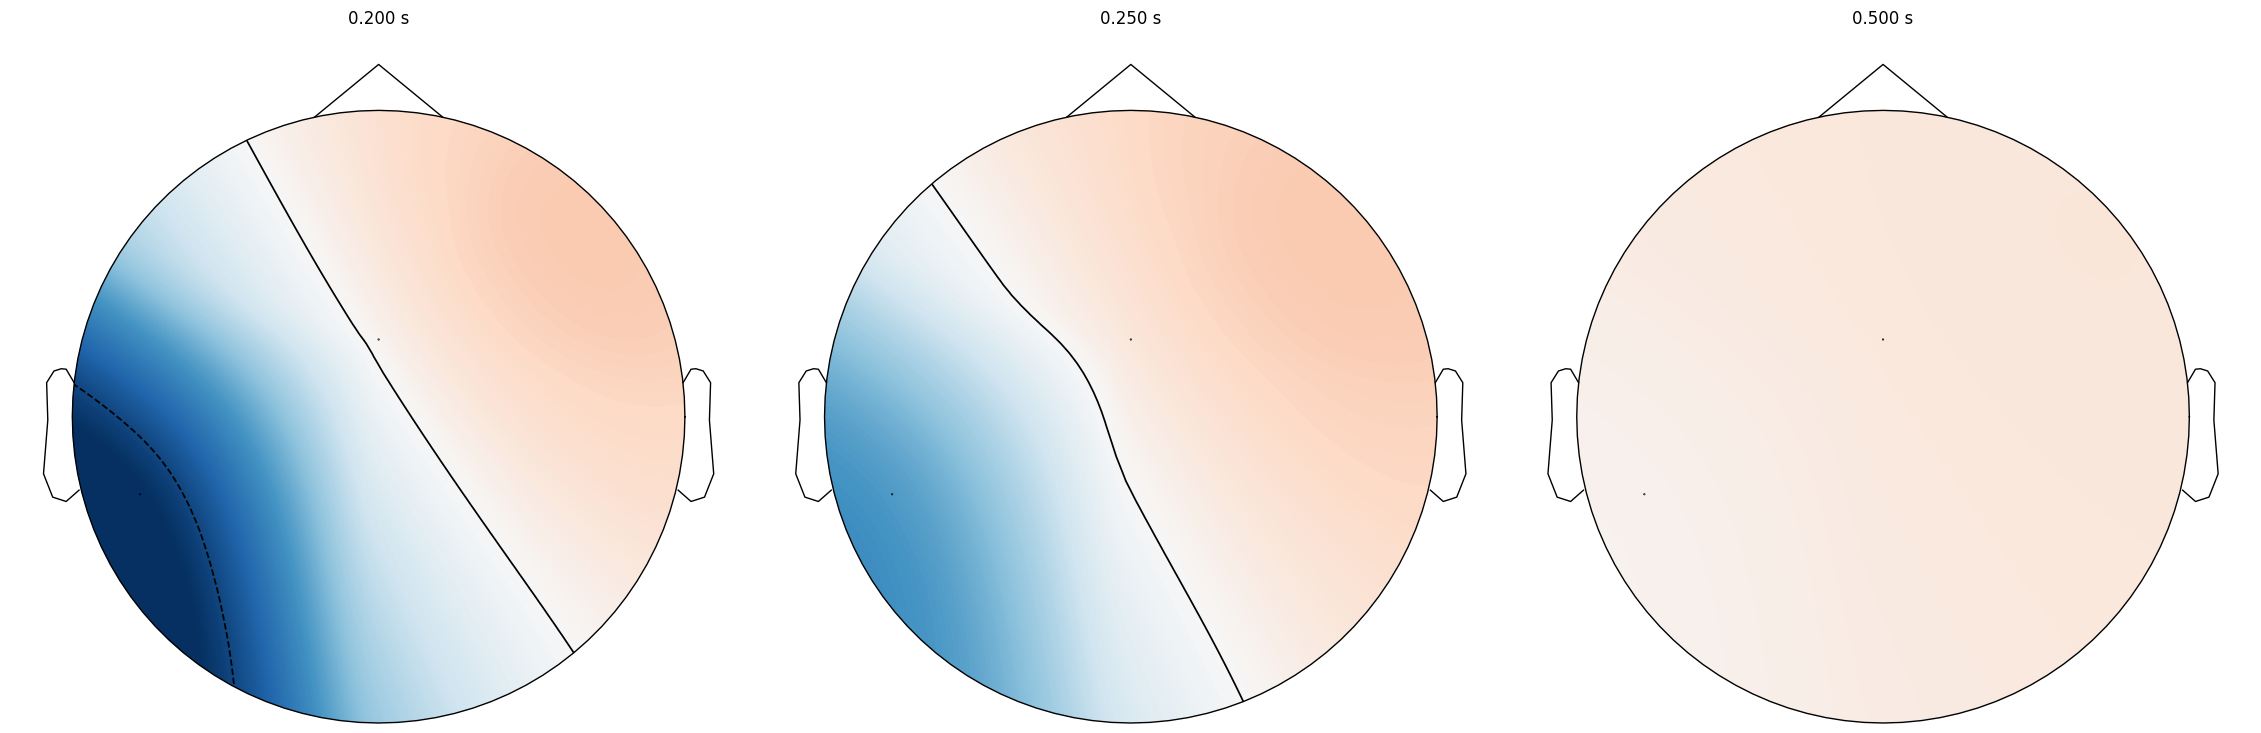

In [102]:
time_points = [.200, .250, .500]


# Plot topomaps for the first evoked (Personal_MMN_erp)

evoked.copy().drop_channels(ls).plot_topomap(
        times=time_points, colorbar=False,contours = 1,size=5,
    )


In [103]:
ls = raw.info['ch_names'].copy()
print(len(ls),ls.pop(38),ls[40])
ls.pop(38)
print(len(ls))

64 FCz TP7
62


In [97]:
del ls[40]

In [98]:
len(ls)

62